<font size="5"><center>Taller de procesamiento de señales

<font size="5">Trabajo práctico N°4

<font size="5">Alumno: Santiago Cabrera

<font size="5">Padrón: 110.445


In [ ]:
!wget https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/MulticlassDiabetesDataset.csv

--2025-10-01 19:16:26--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/MulticlassDiabetesDataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11022 (11K) [text/plain]
Saving to: ‘MulticlassDiabetesDataset.csv.3’

MulticlassDiabetesD 100%[===================>]  10.76K  --.-KB/s    in 0.001s  

2025-10-01 19:16:26 (19.3 MB/s) - ‘MulticlassDiabetesDataset.csv.3’ saved [11022/11022]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
import seaborn as sns

# a) Exploración de datos

In [ ]:
DataFrame = pd.read_csv('/content/MulticlassDiabetesDataset.csv')
DataFrame.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Class
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0
3,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
4,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0


Documentación:

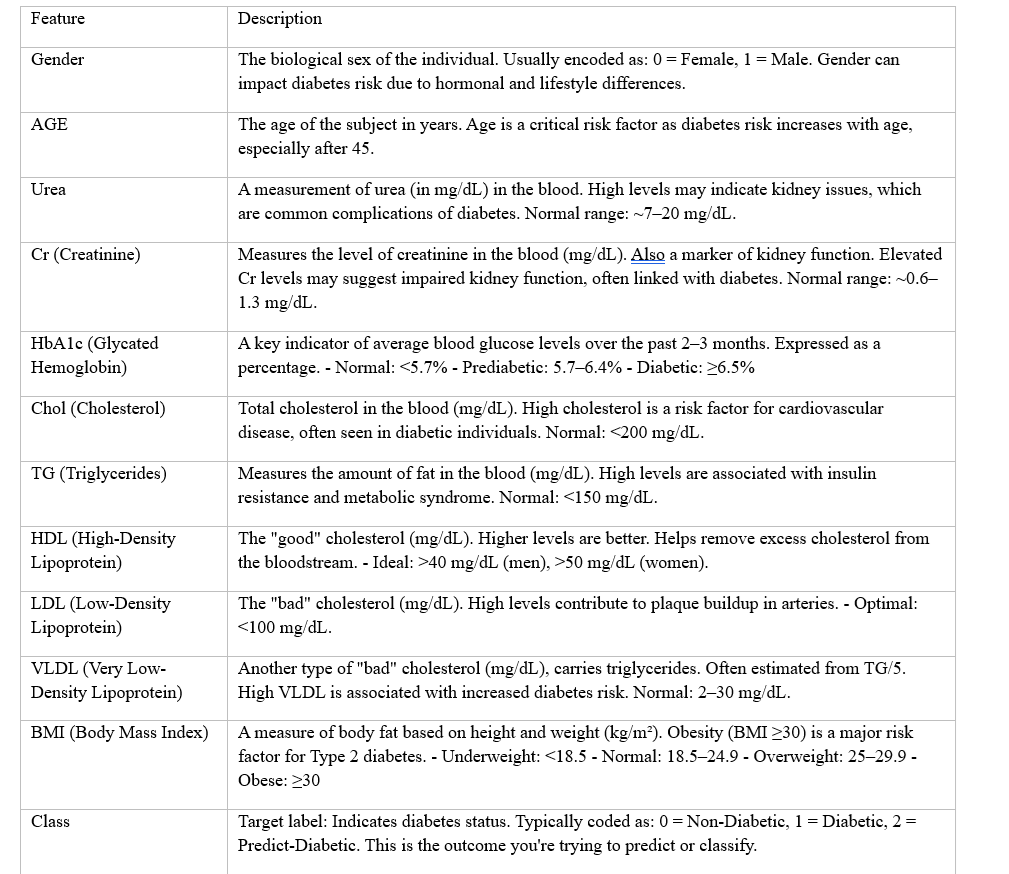

In [ ]:
#Cantidad de muestras por clase

conteo  = DataFrame["Class"].value_counts().sort_index()
print(conteo)
print('\n')
print(f'Hay {conteo[0]} pacientes no diabéticos')
print(f'Hay {conteo[1]} pacientes diabéticos')
print(f'Hay {conteo[2]} pacientes pre diabéticos')



Class
0     96
1     40
2    128
Name: count, dtype: int64


Hay 96 pacientes no diabéticos
Hay 40 pacientes diabéticos
Hay 128 pacientes pre diabéticos


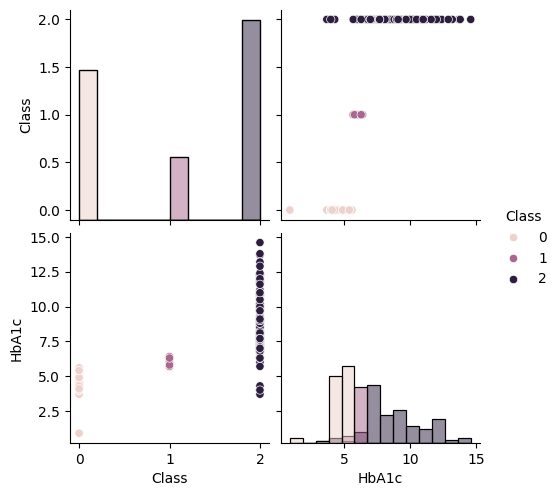

In [ ]:
sns.pairplot(DataFrame, hue = "Class", diag_kind = 'hist', vars = ["Class", "HbA1c"])
plt.grid(True)
plt.show()

La función pairplot toma las columnas del dataset de a pares y grafica su relación.

En la diagonal se ven los histogramas de cada columna.
En las esquinas se observan las relaciones entre las columnas. Cada punto representa una muestra.

Se observa que la columna Hb1Ac está fuertemente relacionada con la de la clase, ya que los pacientes diabéticos tienen un nivel muy particular de HbA1c. También se observa que los pacientes pre-diabéticos tienden a tener niveles elevados de HbA1c

In [ ]:
df_train, df_test = sk.model_selection.train_test_split(DataFrame, train_size = 0.8, shuffle = True) #shuffle debe ser True porque de las clases
#aparecen en orden en el df original


# b) Análisis del discriminante

In [ ]:
class LDA_QDA:
# Inicializar atributos y declarar hiperparámetros.
  def __init__(self, LDA = True): #LDA selecciona entre LDA y QDA
    self.LDA = LDA

    self.clases = [] #lista con las clases posibles

    self.medias = [] #lista con los vecotres de medias (una media por cada clase)
    self.covarianzas = [] #lista con las matrices de covarianza
    self.sigma = None #se usará si LDA == True

    self.Prob_a_priori = [] #lista con las probabilidades a priori para cada posible valor de y

    self.Probas_estimadas = None #Probabilidades estimadas

# Etapa de entrenamiento.
  def fit(self,X,y):

    y = y.to_numpy().flatten() #Sin flatten, y queda de dimensión (n, 1) y no puedo hacer el indexado booleano (debe ser (n,))
    X = X.to_numpy()
    #Los convierto en arreglos de numpy para poder aplicar las funciones de numpy
    self.clases = np.unique(y) #me fijo cuántas clases hay

    for clase in self.clases:
      #probabilidades a priori
      proba_clase = np.sum(y == clase)/len(y)
      self.Prob_a_priori.append(proba_clase)

      #medias
      X_clase = X[y == clase]
      media_clase = np.mean(X_clase, axis = 0)
      self.medias.append(media_clase)

      diff = X_clase - media_clase #Nota: aunque media_clase y X_clase tengan dimensiones distintas, numpy expande las dimensiones de media_clase
      #para centrar los valores
      self.covarianzas.append((1/(X_clase.shape[0] - 1)) * diff.T @ diff )

    if(self.LDA == True):
      self.sigma = np.zeros_like(self.covarianzas[0])
      for clase in self.clases:
        n_clase = sum(y == clase) #numero de elementos en la clase
        self.sigma += (n_clase) * self.covarianzas[clase]

      self.sigma = (1/(len(y) - len(self.clases))) * self.sigma

#Etapa de testeo hard
  def predict(self,X):
    self.predict_prob(X)
    return np.argmax(self.Probas_estimadas, axis = 1)

#Etapa de testeo soft
  def predict_prob(self,X):
    discriminantes = self.predict_discriminant(X)

    n_datos = len(X_test)
    n_clases = len(self.clases)
    self.Probas_estimadas = np.zeros((n_datos, n_clases)) #por cada dato estimo tantas porbabilidades como clases tengo

    for i in range(n_datos):
      disc = discriminantes[i, :]
      exponentes = np.exp(disc)
      self.Probas_estimadas[i, :] = exponentes/np.sum(exponentes)
    return self.Probas_estimadas

#Alternativa prctáica para el testeo soft
  def predict_discriminant(self,X):

    # Para cada dato en X calculo los 3 discriminantes (uno por cada clase)
    if isinstance(X, pd.DataFrame):
      X = X.to_numpy() #X va a ser un df de panda, así que lo tengo q pasar a numpy array

    n_datos = X.shape[0]
    n_clases = len(self.clases)

    discriminantes = np.zeros((n_datos, n_clases)) #Las columnas son las clases distintas. Las filas son los determinantes calculados para cada dato en X

    for clase in self.clases:
      mu = self.medias[clase]
      c_k = self.Prob_a_priori[clase]

      if (self.LDA == True):
        #discriminante: delta_k(x) = mu_k.T * Sigma_inv * x - 0.5 * mu_k.T * Sigma_inv * mu_k + log(c_k)
        sigma_inv = np.linalg.inv(self.sigma)

        #Al parecer tengo que asegurarme de que mu sea un vector columna para hacer matmul
        if mu.ndim == 1:
          mu = mu.reshape(-1, 1) #el -1 le dice a numy que complete la dimensión como convenga y el 1 le dice que el número de columnas debe ser 1
          #es decir, pasa a ser un vector columna

        termino1 = mu.T @ sigma_inv @ X.T
        #Cada dato en X debe ser tratado como un vector columna. De ahí la transposición
        termino2 = 0.5 * mu.T @ sigma_inv @ mu
        termino3 = np.log(c_k)

        # Assign the calculated discriminants to the correct column, flattening term1
        discriminantes[:, clase] = termino1.flatten() - termino2 + termino3


      else:
        #Discriminante: delta_k(x) = - 0.5 * (x - mu_k).T * Sigma_k_inv * (x - mu_k) -0.5 * log(det(Sigma_k)) + log(c_k)
        sigma_k = self.covarianzas[clase]
        sigma_k_inv = np.linalg.inv(sigma_k)
        log_det_sigma_k = np.log(np.linalg.det(sigma_k))

        for i in range(n_datos):
          x = X[i]
          diff = x - mu

          if diff.ndim == 1: #otra vez, diff debe ser vetcor columna
              diff = diff.reshape(-1, 1)
          cuadratico = diff.T @ sigma_k_inv @ diff

          cuadratico = cuadratico.item()#con la linea de antes cuadrático es una matriz de 1x1. Lo tengo que pasar a un escalar, si no numpy me tira un warning

          discriminantes[i, clase] = - 0.5 * cuadratico -0.5 * log_det_sigma_k + np.log(c_k)

    return discriminantes


  def accuracy(self, X, y):
    predict = self.predict(X)

    if isinstance(y, pd.DataFrame):
      y = y.to_numpy().flatten()

    arr_iguales = np.where(predict == y, 1, 0) #pone un uno donde coinidan. O en otro caso
    accuracy = np.mean(arr_iguales)
    return accuracy

  def matriz_de_confusion(self, X, y):

    n_clases = len(self.clases)

    matriz_de_conf = np.zeros((n_clases, n_clases))

    predict = self.predict(X)

    if isinstance(y, pd.DataFrame):
      y = y.to_numpy().flatten()

    for clase_real in self.clases:
      index = np.where(y == clase_real, True, False) #vector de indices booleanos
      predict_index = predict[index] #filtro los resultados por clase.
      #Me quedo con los resultados donde la clase verdadera es la clase 0, luego la 1 y luego la 2

      for clase_predicha in self.clases:
        veces = np.sum(np.where(predict_index == clase_predicha, 1, 0)) #veces que predije clase_predicha cuando era clase_real
        matriz_de_conf[clase_real, clase_predicha] = veces

    return matriz_de_conf

  def precisions_recalls(self, X, y): #ca
    matriz_de_conf = self.matriz_de_confusion(X, y)
    precisions = []
    recalls = []

    for clase in self.clases:
      verdaderos_positivos = matriz_de_conf[clase, clase] #en la diagonal de la matriz están las clasificaciones correctas

      falsos_positivos = np.sum(matriz_de_conf[:, clase]) - verdaderos_positivos
      #son los elementos de la primer columna, menos los elementos bien clasificados

      falsos_negativos = np.sum(matriz_de_conf[clase, :]) - verdaderos_positivos #los que no clasifiqué como clase 0 que en realidad si eran
      #son los elementos de la primer fila que en realidad menos los bien clasificados

      precision = verdaderos_positivos / (verdaderos_positivos + falsos_positivos) if (verdaderos_positivos + falsos_positivos) > 0 else 0
      #cuántos positivos de más estoy prediciendo
      #Da 0 cuando no tengo verdaderos positivos ni falsos positivos (pasa en la clase 1 porque el modelo nunca predice clase 1)
      #como no estoy estimando positivos de más, lo asigno en 0
      precisions.append(precision)

      recall = verdaderos_positivos / (verdaderos_positivos + falsos_negativos) if (verdaderos_positivos + falsos_negativos) > 0 else 0
      #cuántos falsos negativos. Cuántos estoy dejando afuera
      recalls.append(recall)

    return precisions, recalls

  def macro_F1(self, X, y):
    f1_list = []
    precisions, recalls = self.precisions_recalls(X, y)

    for clase in self.clases:
      precision = precisions[clase]
      recall = recalls[clase]
      f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
      f1_list.append(f1)

    return np.mean(f1_list)


## Una columna de datos

In [ ]:
X_train = df_train[["HbA1c"]]
y_train = df_train[["Class"]]

X_test = df_test[["HbA1c"]]
y_test = df_test[["Class"]]

In [ ]:
#Entreno LDA
lda = LDA_QDA(LDA = True)
lda.fit(X_train, y_train)

In [ ]:
lda_predict = lda.predict(X_test)
print(lda_predict[0:5])
print(y_test[0:5])

[0 2 2 0 0]
     Class
34       0
218      2
230      2
60       0
95       0


In [ ]:
#Entreno QDA
qda = LDA_QDA(LDA = False)
qda.fit(X_train, y_train)
qda_predict = qda.predict(X_test)
print(qda_predict[0:5])
print(y_test[0:5])

[0 2 2 0 0]
     Class
34       0
218      2
230      2
60       0
95       0


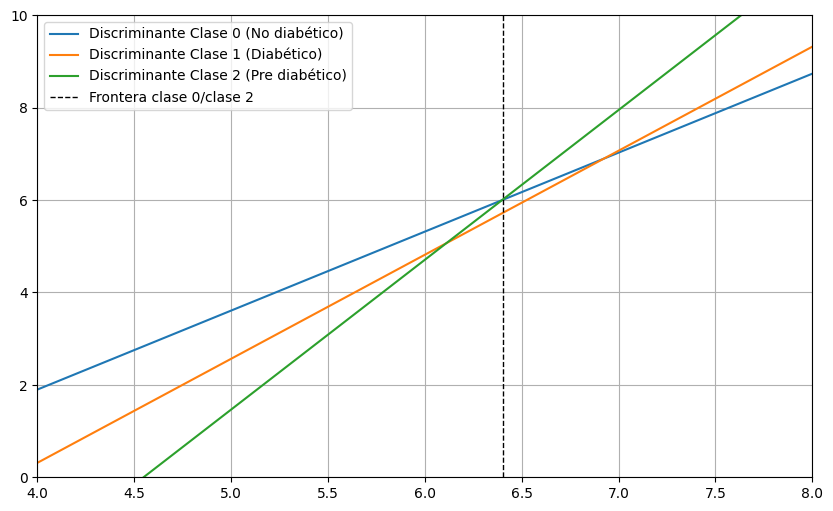

In [ ]:
#Grafico de las funciones discriminante y las fronteras de decisión
HbA1c_ini = df_test[["HbA1c"]].min().iloc[0] #sin el .iloc[0] devuelve una serie de pandas
HbA1c_fin = df_test[["HbA1c"]].max().iloc[0]
rango = np.linspace(start = HbA1c_ini, stop = HbA1c_fin, num = 1000)



discriminante = lda.predict_discriminant(rango.reshape(-1, 1)) #predict_discriminant espera un vector columna de datos

disc_clase0 = discriminante[:, 0].flatten()
disc_clase1 = discriminante[:, 1].flatten()
disc_clase2 = discriminante[:, 2].flatten()

plt.figure(figsize=(10, 6))
plt.plot(rango, disc_clase0, label='Discriminante Clase 0 (No diabético)')
plt.plot(rango, disc_clase1, label='Discriminante Clase 1 (Diabético)')
plt.plot(rango, disc_clase2, label='Discriminante Clase 2 (Pre diabético)')

indice = np.argmin(np.abs(disc_clase0 - disc_clase2)) #busco dónde se minimiza la distancia entre los discriminantes. En ese punto está la forntera de decisión
x_frontera = rango[indice]

plt.axvline(x = x_frontera, color = 'k', linestyle = '--', linewidth = 1, label = 'Frontera clase 0/clase 2')

plt.xlim(4,8)

plt.ylim(0, 10)

plt.legend()
plt.grid(True)
plt.show()

Observación: El modelo nunca predice clase 1

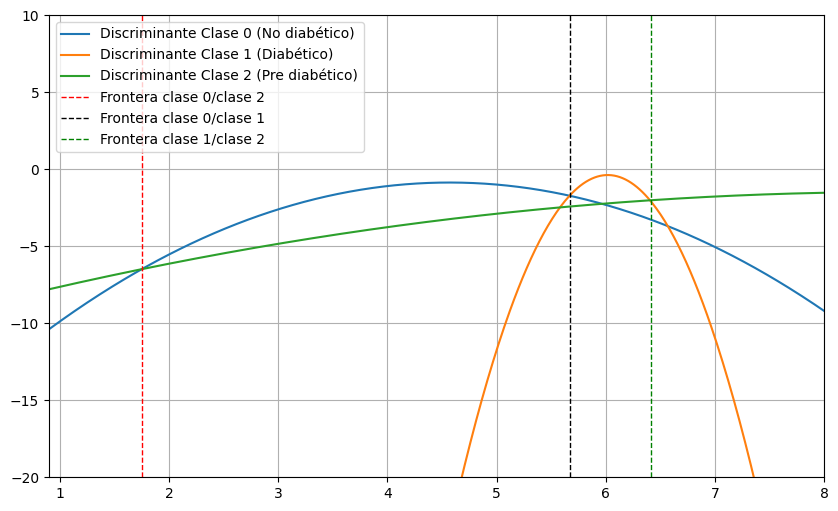

In [ ]:
discriminantes_qda = qda.predict_discriminant(rango.reshape(-1, 1))

disc_qda_c0 = discriminantes_qda[:, 0].flatten()
disc_qda_c1 = discriminantes_qda[:, 1].flatten()
disc_qda_c2 = discriminantes_qda[:, 2].flatten()

plt.figure(figsize=(10, 6))
plt.plot(rango, disc_qda_c0, label='Discriminante Clase 0 (No diabético)')
plt.plot(rango, disc_qda_c1, label='Discriminante Clase 1 (Diabético)')
plt.plot(rango, disc_qda_c2, label='Discriminante Clase 2 (Pre diabético)')


#Frontera clase 0/clase 2
c0c2_arr = np.where(disc_qda_c0 > disc_qda_c2, 1, 0) #1 donde c0 sea mayor a c1. Donde cambia el valor está el cruce
indc0c2 = np.argmax(c0c2_arr) #indice del primer cruce
x_c0c2 = rango[indc0c2] #valor de HbA1c en el cruce
plt.axvline(x = x_c0c2, color = 'r', linestyle = '--', linewidth = 1, label = 'Frontera clase 0/clase 2')


#Frontera clase 0/clase 1
c0c1_arr = np.where(disc_qda_c1 > disc_qda_c0, 1, 0)
indc0c1 = np.argmax(c0c1_arr)
x_c0c1 = rango[indc0c1]
plt.axvline(x = x_c0c1, color = 'k', linestyle = '--', linewidth = 1, label = 'Frontera clase 0/clase 1')

#Frontera clase 1/clase 2
#Frontera clase 1/clase 2
c1c2_arr = np.where(disc_qda_c2 > disc_qda_c1, 1, 0)
c1c2_arr = c1c2_arr[indc0c1:] #solo me interesa lo que pasa a partir de indc0c1. Trunco el array
indc1c2 = np.argmax(c1c2_arr, axis = 0) + indc0c1
x_c1c2 = rango[indc1c2]
plt.axvline(x = x_c1c2, color = 'g', linestyle = '--', linewidth = 1, label = 'Frontera clase 1/clase 2')

#Agregué estps límites para que el gráfico se viera mejor
plt.xlim(HbA1c_ini, 8)
plt.ylim(-20, 10)

plt.grid(True)
plt.legend()



Observación: Este modelo sí es capaz de predecir clase 1 para un intervalo del nivel de HbA1c

In [ ]:
accuracy_LDA = lda.accuracy(X_test, y_test)
print(f'El accuracy del algoritmo LDA es {accuracy_LDA}')

El accuracy del algoritmo LDA es 0.8301886792452831


In [ ]:
accuracy_QDA = qda.accuracy(X_test, y_test)
print(f'El accuracy del algoritmo QDA es {accuracy_QDA}')

El accuracy del algoritmo QDA es 0.9811320754716981


In [ ]:
matriz_de_conf_LDA = lda.matriz_de_confusion(X_test, y_test)

print('Matriz de confusión para el algoritmo LDA:\n')
print(matriz_de_conf_LDA)


Matriz de confusión para el algoritmo LDA:

[[21.  0.  0.]
 [ 9.  0.  0.]
 [ 0.  0. 23.]]


In [ ]:
matriz_de_conf_QDA = qda.matriz_de_confusion(X_test, y_test)
print('Matriz de confusión para el algoritmo QDA:\n')
print(matriz_de_conf_QDA)

Matriz de confusión para el algoritmo QDA:

[[20.  0.  1.]
 [ 0.  9.  0.]
 [ 0.  0. 23.]]


In [ ]:
precisions, recalls = lda.precisions_recalls(X_test, y_test)
print(f"precisions por clase: {precisions}")
print(f"recalls por clase: {recalls}")
print(f"\nMacro F1 Score para LDA: {lda.macro_F1(X_test, y_test)}")


precisions por clase: [np.float64(0.7), 0, np.float64(1.0)]
recalls por clase: [np.float64(1.0), np.float64(0.0), np.float64(1.0)]

Macro F1 Score para LDA: 0.6078431372549019


In [ ]:
precisions, recalls = qda.precisions_recalls(X_test, y_test)
print(f"precisions por clase: {precisions}")
print(f"recalls por clase: {recalls}")
print(f"\nMacro F1 Score para QDA: {qda.macro_F1(X_test, y_test)}")


precisions por clase: [np.float64(1.0), np.float64(1.0), np.float64(0.9583333333333334)]
recalls por clase: [np.float64(0.9523809523809523), np.float64(1.0), np.float64(1.0)]

Macro F1 Score para QDA: 0.9847777201176267


Observación: el accuracy y la macro-F1 del algoritmo QDA son mucho mejores que las del algoritmo LDA porque el segundo es incapaz de predecir clase 1.

Eso reducec el accuracy porque todas las muestras que efectivamente pertenecen a la clase 1 estarán mal clasificadas y reduce la macro-F1 porque la F1-score para la clase 1 será 0.

## Dos columnas de datos

In [ ]:
X_train2 = df_train[["HbA1c", "BMI"]]
y_train2 = df_train[["Class"]]

X_test2 = df_test[["HbA1c", "BMI"]]
y_test2 = df_test[["Class"]]

lda2 = LDA_QDA(LDA = True)
qda2 = LDA_QDA(LDA = False)

lda2.fit(X_train2, y_train2)
qda2.fit(X_train2, y_train2)

In [ ]:
#Rangos
hba1c_min, hba1c_max = X_train2['HbA1c'].min(), X_train2['HbA1c'].max()
bmi_min, bmi_max = X_train2['BMI'].min(), X_train2['BMI'].max()

h = .02  #tamaño del paso
xx, yy = np.meshgrid(np.arange(hba1c_min - 1, hba1c_max + 1, h),
                     np.arange(bmi_min - 5, bmi_max + 5, h))
#Nota: xx e yy son matrices de 1713x785
#xx representa los valores de HbA1c en la grilla. Idem yy con BMI
#todas las filas de xx son iguales. HbA1c varía en el eje horizontal y es constante en el vertical
#todas las columnas de yy son iguales. BMI varía en el eje vertical
#la coordenada (HbA1c, BMI) se representa con el punto (xx[i, j], yy[i, j]

In [ ]:
grid_points = np.vstack((xx.ravel(), yy.ravel())).T
#.ravel() aplana las matrices en un array unidimensional.
#vstack los apila.
#hay que trasponerlo porque predict_discriminant espera los una matriz donde cada fila sea un dato

Z_lda = lda2.predict_discriminant(grid_points)
#Z_lda contiene los discriminantes (uno por clase) para cada punto de la cuadrícula
#Z_lda.shape() = (1344705, 3)
#la primer columna es la clase 0, la segunda la 1 y la tercera la 2

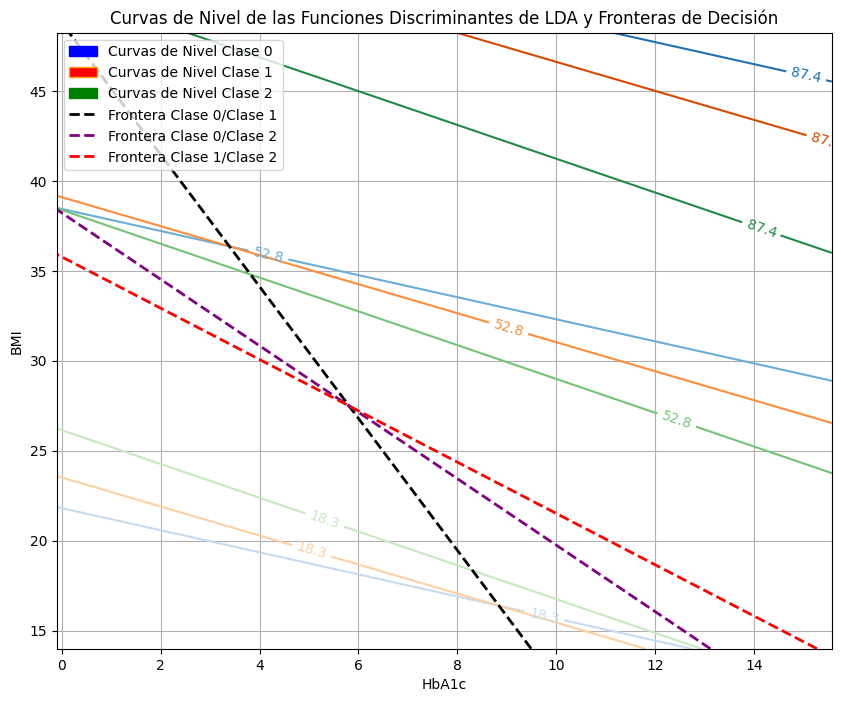

In [ ]:
Z_lda_clase0 = Z_lda[:, 0].reshape(xx.shape)
Z_lda_clase1 = Z_lda[:, 1].reshape(xx.shape)
Z_lda_clase2 = Z_lda[:, 2].reshape(xx.shape)

#cada una de estas 3 funciones representa los valores de los 3 discriminantes, evauluados en cada punto de la grilla

plt.figure(figsize=(10, 8))

niveles_lda = np.linspace(Z_lda.min(), Z_lda.max(), num = 5)

contour_clase0 = plt.contour(xx, yy, Z_lda_clase0, levels = niveles_lda, cmap='Blues')
plt.clabel(contour_clase0, inline=1, fontsize=10) #escribe el valor del discriminante en esa curva de nivel

contour_clase1 = plt.contour(xx, yy, Z_lda_clase1, levels = niveles_lda, cmap='Oranges')
plt.clabel(contour_clase1, inline=1, fontsize=10)

contour_clase2 = plt.contour(xx, yy, Z_lda_clase2, levels = niveles_lda, cmap='Greens')
plt.clabel(contour_clase2, inline=1, fontsize=10)

#frontera Clase 0/Clase 1
contour_c0c1 = plt.contour(xx, yy, Z_lda_clase0 - Z_lda_clase1, levels=[0], colors='k', linewidths=2, linestyles='--')

#frontera clase 0/clase 2
contour_c0c2 = plt.contour(xx, yy, Z_lda_clase0 - Z_lda_clase2, levels=[0], colors='purple', linewidths=2, linestyles='--')

#frontera clase 1/clase 2
contour_c1c2 = plt.contour(xx, yy, Z_lda_clase1 - Z_lda_clase2, levels=[0], colors='red', linewidths=2, linestyles='--')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


legend_elements = [
    Patch(facecolor='blue', edgecolor='blue', label='Curvas de Nivel Clase 0'),
    Patch(facecolor='red', edgecolor='orange', label='Curvas de Nivel Clase 1'),
    Patch(facecolor='green', edgecolor='green', label='Curvas de Nivel Clase 2'),
    Line2D([0], [0], color='k', lw=2, linestyle='--', label='Frontera Clase 0/Clase 1'),
    Line2D([0], [0], color='purple', lw=2, linestyle='--', label='Frontera Clase 0/Clase 2'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Frontera Clase 1/Clase 2')
]#esto crea la leyenda a mano

plt.xlabel('HbA1c')
plt.ylabel('BMI')
plt.title('Curvas de Nivel de las Funciones Discriminantes de LDA y Fronteras de Decisión')
plt.grid(True)
plt.legend(handles = legend_elements)
plt.show()

In [ ]:
Z_qda = qda2.predict_discriminant(grid_points)

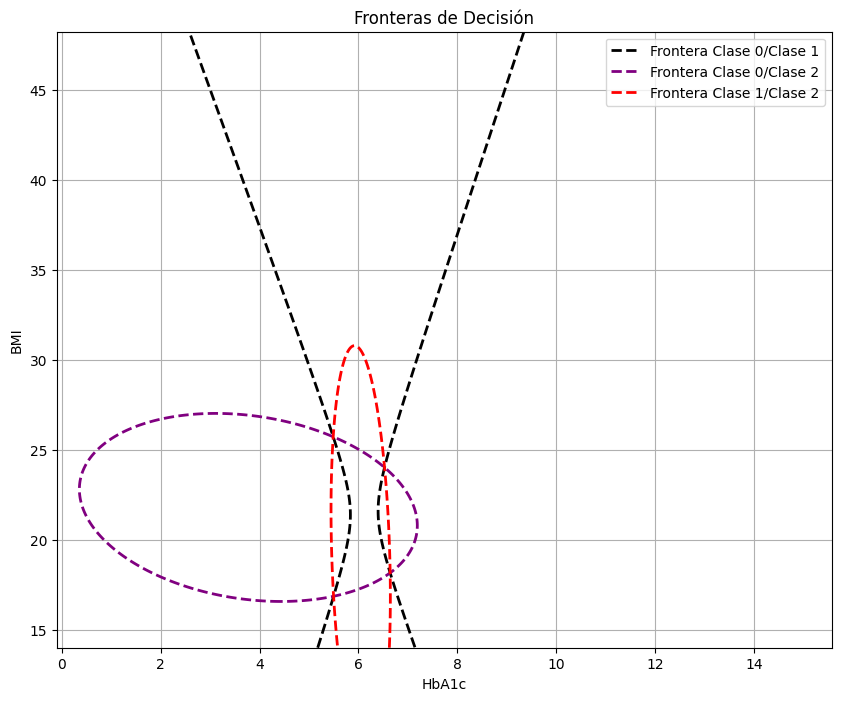

In [ ]:
Z_qda_clase0 = Z_qda[:, 0].reshape(xx.shape)
Z_qda_clase1 = Z_qda[:, 1].reshape(xx.shape)
Z_qda_clase2 = Z_qda[:, 2].reshape(xx.shape)

plt.figure(figsize=(10, 8))

#frontera Clase 0/Clase 1
frontera_c0_c1 = plt.contour(xx, yy, Z_qda_clase0 - Z_qda_clase1, levels=[0], colors='k', linewidths=2, linestyles='--')

#frontera Clase 0/ Clase 2
frontera_c0_c2 = plt.contour(xx, yy, Z_qda_clase0 - Z_qda_clase2, levels=[0], colors='purple', linewidths=2, linestyles='--')

#frontera Clase 1/clase 2
frontera_c1_c2 = plt.contour(xx, yy, Z_qda_clase1 - Z_qda_clase2, levels=[0], colors='red', linewidths=2, linestyles='--')

leyenda_fronteras = [
    Line2D([0], [0], color='k', lw=2, linestyle='--', label='Frontera Clase 0/Clase 1'),
    Line2D([0], [0], color='purple', lw=2, linestyle='--', label='Frontera Clase 0/Clase 2'),
    Line2D([0], [0], color='red', lw=2, linestyle='--', label='Frontera Clase 1/Clase 2')
]

plt.xlabel('HbA1c')

plt.ylabel('BMI')

plt.title('Fronteras de Decisión')
plt.grid(True)
plt.legend(handles = leyenda_fronteras)
plt.show()


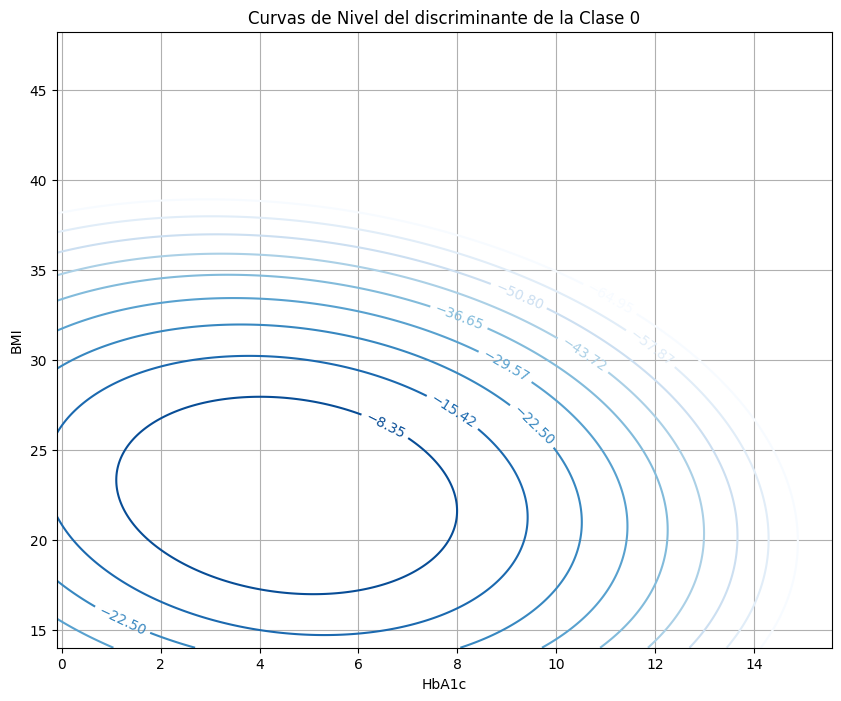

In [ ]:
#curvas de nivel del discriminante de la clase 0
plt.figure(figsize=(10, 8))

niveles_c0 = np.linspace(Z_qda_clase0.mean(), Z_qda_clase0.max(), num = 10)

contour_clase0 = plt.contour(xx, yy, Z_qda_clase0, levels = niveles_c0, cmap='Blues')
plt.clabel(contour_clase0, inline=1, fontsize=10)

plt.grid(True)

plt.xlabel('HbA1c')

plt.ylabel('BMI')

plt.title('Curvas de Nivel del discriminante de la Clase 0')
plt.show()

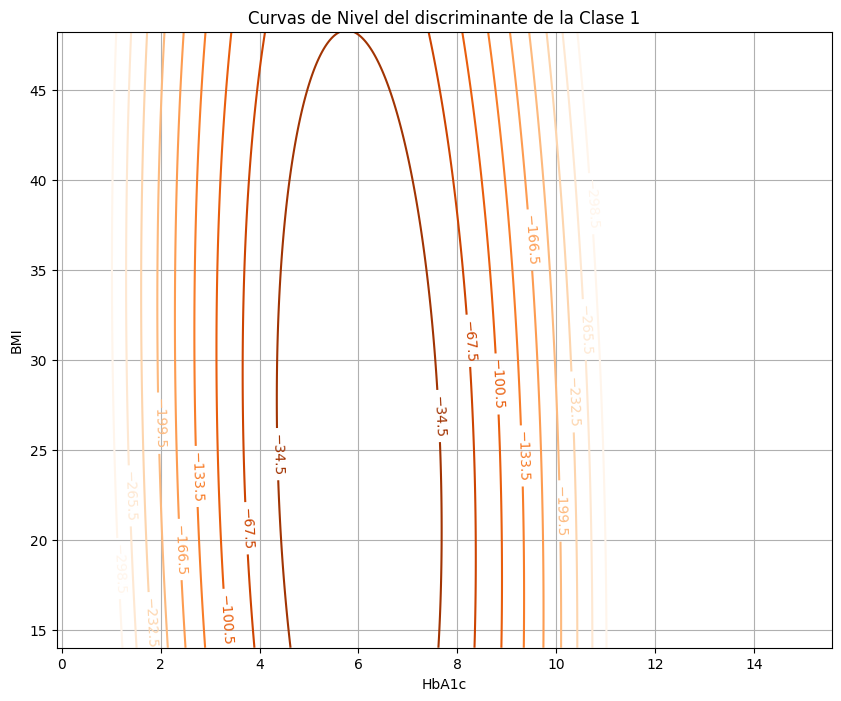

In [ ]:
#Curvas de nivel del discriminante de la clase 1
plt.figure(figsize=(10, 8))

niveles_c1 = np.linspace(Z_qda_clase1.mean(), Z_qda_clase1.max(), num = 10)

contour_clase1 = plt.contour(xx, yy, Z_qda_clase1, levels = niveles_c1, cmap='Oranges')
plt.clabel(contour_clase1, inline=1, fontsize=10)

plt.grid(True)

plt.xlabel('HbA1c')

plt.ylabel('BMI')

plt.title('Curvas de Nivel del discriminante de la Clase 1')
plt.show()

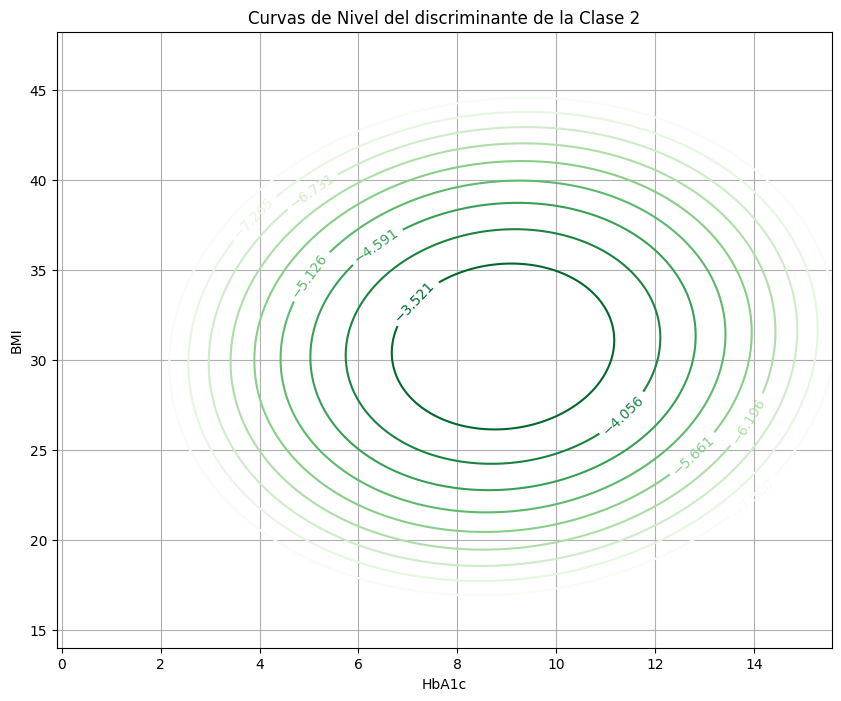

In [ ]:
#Curvas de nivel del discriminante de la clase 2

plt.figure(figsize=(10, 8))

niveles_c2 = np.linspace(Z_qda_clase2.mean(), Z_qda_clase2.max(), num = 10)

contour_clase2 = plt.contour(xx, yy, Z_qda_clase2, levels = niveles_c2, cmap='Greens')
plt.clabel(contour_clase2, inline=1, fontsize=10)

plt.grid(True)

plt.xlabel('HbA1c')

plt.ylabel('BMI')

plt.title('Curvas de Nivel del discriminante de la Clase 2')
plt.show()

In [ ]:
print(f'Accuracy LDA: {lda2.accuracy(X_test2, y_test2)}')
print(f'Accuracy QDA: {qda2.accuracy(X_test2, y_test2)}')

Accuracy LDA: 0.7924528301886793
Accuracy QDA: 0.9622641509433962


In [ ]:
print('Matriz de confusión para la clase LDA: \n')
print(lda2.matriz_de_confusion(X_test2, y_test2))
print('Matriz de confusión para la clase QDA: \n')
print(qda2.matriz_de_confusion(X_test2, y_test2))

Matriz de confusión para la clase LDA: 

[[18.  0.  0.]
 [ 9.  0.  1.]
 [ 1.  0. 24.]]
Matriz de confusión para la clase QDA: 

[[18.  0.  0.]
 [ 0.  9.  1.]
 [ 0.  1. 24.]]


In [ ]:
print(f"\nMacro F1 Score para LDA: {lda2.macro_F1(X_test2, y_test2)}")
print(f"\nMacro F1 Score para QDA: {qda2.macro_F1(X_test2, y_test2)}")


Macro F1 Score para LDA: 0.5808695652173913

Macro F1 Score para QDA: 0.9533333333333333


Observación: La clase QDA entrenada con 2 columnas de datos tiene peor macro-F1 que la entrenada solo con una columna de datos

## Todas las columnas de datos

In [ ]:
print(df_train.columns)

Index(['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL',
       'VLDL', 'BMI', 'Class'],
      dtype='object')


In [ ]:
X_train3 = df_train[['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']]
y_train3 = df_train[["Class"]]

X_test3 = df_test[['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']]
y_test3 = df_test[["Class"]]

In [ ]:
lda3 = LDA_QDA(LDA = True)
qda3 = LDA_QDA(LDA = False)

lda3.fit(X_train3, y_train3)
qda3.fit(X_train3, y_train3)

In [ ]:
print(f'Accuracy LDA: {lda3.accuracy(X_test3, y_test3)}')
print(f'Accuracy QDA: {qda3.accuracy(X_test3, y_test3)}')

Accuracy LDA: 0.7924528301886793
Accuracy QDA: 0.8113207547169812


In [ ]:
print('Matriz de confusión para la clase LDA: \n')
print(lda3.matriz_de_confusion(X_test3, y_test3))
print('Matriz de confusión para la clase QDA: \n')
print(qda3.matriz_de_confusion(X_test3, y_test3))

Matriz de confusión para la clase LDA: 

[[16.  2.  0.]
 [ 8.  2.  0.]
 [ 1.  0. 24.]]
Matriz de confusión para la clase QDA: 

[[15.  1.  2.]
 [ 4.  6.  0.]
 [ 1.  2. 22.]]


In [ ]:
print(f"\nMacro F1 Score para LDA: {lda3.macro_F1(X_test3, y_test3)}")
print(f'\nMacro F1 Score para QDA: {qda3.macro_F1(X_test3, y_test3)}')


Macro F1 Score para LDA: 0.6698307229868692

Macro F1 Score para QDA: 0.7730039384174723


Observación: agregué un monton de datos, pero las métricas empeoraron

# c) Vecinos más cercanos

In [ ]:
class KNN:
  # Inicializar atributos y declarar hiperpar´ametros.
  def __init__(self,X, y, N):
    #guardar memoria para el fiteo
    self.X = None
    self.y = None
    self.N = N
    self.clases = np.unique(y)
    self.Probas_estimadas = None

  # Etapa de entrenamiento.
  def fit(self,X,y):
    #guardar los datos
    if isinstance(X, pd.DataFrame):
      X = X.to_numpy()

    self.X = X #cada dato es una fila. Para HbA1c (211, 1). Para HbA1c y BMI es (211,2) y así

    if isinstance(y, pd.DataFrame):
      y = y.to_numpy().flatten()

    self.y = y

  # Etapa de testeo soft
  def predict_proba(self,X):
    if isinstance(X, pd.DataFrame):
      X = X.to_numpy()

    n_datos = X.shape[0]
    n_clases = len(self.clases)

    self.Probas_estimadas = np.zeros((n_datos, n_clases)) #Para cada elemento en X estimo una proba por clase

    for i in range(n_datos):

      dist = np.sqrt(np.sum((self.X - X[i, :])**2, axis=1))
      #creo q sería distances = np.sqrt(np.sum((self.X - X[i, :])**2, axis=1))

      vecinos_cercanos_indices = np.argsort(dist)[:self.N]
      #np.argsort devuelve los indices que ordenarían el array. Me quedo con los primeros N

      vecinos_cercanos_clases = self.y[vecinos_cercanos_indices]

      class_counts = np.bincount(vecinos_cercanos_clases, minlength = n_clases)
      #np.bincounts devuelve un array en donde el i-ésimo elemento es la cantidad de veces que aparece i en el array de entrada (que debe ser de enteros)
      #o sea, array[i] = cantidad de veces que aparece i
      #minlength = n_clases para que haya tantos elemetos como clases

      self.Probas_estimadas[i, :] = class_counts / self.N

    return self.Probas_estimadas

  # Etapa de testeo hard
  def predict(self,X):
    self.predict_proba(X)
    return np.argmax(self.Probas_estimadas, axis = 1)

  def accuracy(self, X, y):
    predict = self.predict(X)

    if isinstance(y, pd.DataFrame):
      y = y.to_numpy().flatten()

    arr_iguales = np.where(predict == y, 1, 0) #pone un uno donde coinidan. O en otro caso
    accuracy = np.mean(arr_iguales)
    return accuracy

  def matriz_de_confusion(self, X, y):

    n_clases = len(self.clases)

    matriz_de_conf = np.zeros((n_clases, n_clases))

    predict = self.predict(X)

    if isinstance(y, pd.DataFrame):
      y = y.to_numpy().flatten()

    for clase_real in self.clases:
      index = np.where(y == clase_real, True, False) #vector de indices booleanos
      predict_index = predict[index] #filtro los resultados por clase.
      #Me quedo con los resultados donde la clase verdadera es la clase 0, luego la 1 y luego la 2

      for clase_predicha in self.clases:
        veces = np.sum(np.where(predict_index == clase_predicha, 1, 0)) #veces que predije clase_predicha cuando era clase_real
        matriz_de_conf[clase_real, clase_predicha] = veces

    return matriz_de_conf

  def precisions_recalls(self, X, y):
    matriz_de_conf = self.matriz_de_confusion(X, y)
    precisions = []
    recalls = []

    for clase in self.clases:
      verdaderos_positivos = matriz_de_conf[clase, clase] #en la diagonal de la matriz están las clasificaciones correctas

      falsos_positivos = np.sum(matriz_de_conf[:, clase]) - verdaderos_positivos
      #son los elementos de la primer columna, menos los elementos bien clasificados

      falsos_negativos = np.sum(matriz_de_conf[clase, :]) - verdaderos_positivos #los que no clasifiqué como clase 0 que en realidad si eran
      #son los elementos de la primer fila que en realidad menos los bien clasificados

      precision = verdaderos_positivos / (verdaderos_positivos + falsos_positivos) if (verdaderos_positivos + falsos_positivos) > 0 else 0
      #cuántos positivos de más estoy prediciendo
      #Da 0 cuando no tengo verdaderos positivos ni falsos positivos (pasa en la clase 1 porque el modelo nunca predice clase 1)
      #como no estoy estimando positivos de más, lo asigno en 0
      precisions.append(precision)

      recall = verdaderos_positivos / (verdaderos_positivos + falsos_negativos) if (verdaderos_positivos + falsos_negativos) > 0 else 0
      #cuántos falsos negativos. Cuántos estoy dejando afuera
      recalls.append(recall)

    return precisions, recalls

  def macro_F1(self, X, y):
    f1_list = []
    precisions, recalls = self.precisions_recalls(X, y)

    for clase in self.clases:
      precision = precisions[clase]
      recall = recalls[clase]
      f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
      f1_list.append(f1)

    return np.mean(f1_list)




In [ ]:
vmc = KNN(X_train, y_train, 9) #vmc por vecinos más cercanos
vmc.fit(X_train, y_train)

print(vmc.predict(X_test)[0:10])
print(y_test.iloc[0:10])


[1 1 1 0 1 1 2 1 2 1]
     Class
118      1
113      1
228      2
10       0
122      1
107      1
185      2
258      2
193      2
177      2


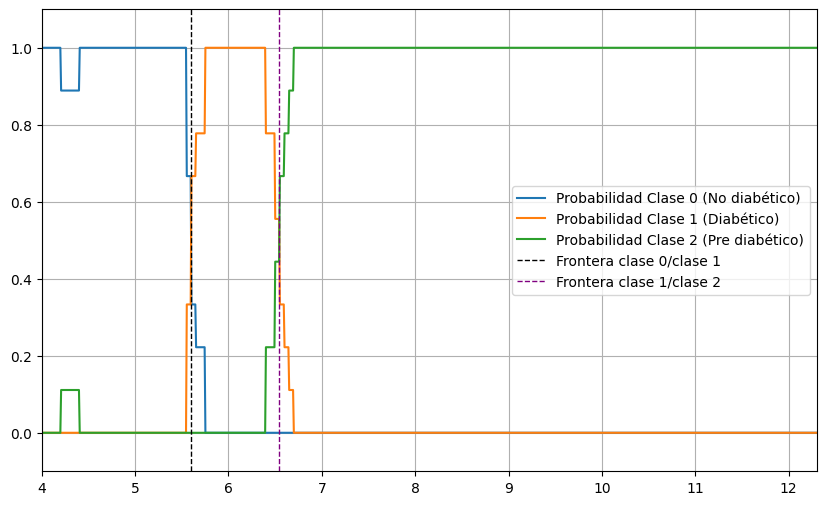

In [ ]:
rango = np.linspace(start = HbA1c_ini, stop = HbA1c_fin, num = 1000)
probas = vmc.predict_proba(rango.reshape(-1, 1))

probas_clase0 = probas[:, 0]
probas_clase1 = probas[:, 1]
probas_clase2 = probas[:, 2]

plt.figure(figsize=(10, 6))

plt.plot(rango, probas_clase0, label='Probabilidad Clase 0 (No diabético)')
plt.plot(rango, probas_clase1, label='Probabilidad Clase 1 (Diabético)')
plt.plot(rango, probas_clase2, label='Probabilidad Clase 2 (Pre diabético)')

clases_estimadas = vmc.predict(rango.reshape(-1, 1))
clase0_indices = np.where(clases_estimadas == 0, True, False)
x_frontera_c0c1 = rango[clase0_indices][-1] #agarro el último elemento de rango en el que el algoritmo predice clase 0

plt.axvline(x = x_frontera_c0c1, color = 'k', linestyle = '--', linewidth = 1, label = 'Frontera clase 0/clase 1')

clase1_indices = np.where(clases_estimadas == 1, True, False)
x_frontera_c1c2 = rango[clase1_indices][-1]

plt.axvline(x = x_frontera_c1c2, color = 'purple', linestyle = '--', linewidth = 1, label = 'Frontera clase 1/clase 2')

plt.xlim(HbA1c_ini, HbA1c_fin)

plt.ylim(-0.1, 1.1)

plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print(f'Accuracy 9NN: {vmc.accuracy(X_test, y_test)}')

Accuracy 9NN: 0.9056603773584906


In [ ]:
print('Matriz de confusión para la clase 9NN: \n')
print(vmc.matriz_de_confusion(X_test, y_test))


Matriz de confusión para la clase 9NN: 

[[18.  0.  0.]
 [ 0. 10.  0.]
 [ 0.  5. 20.]]


In [ ]:
print(f"Macro F1 Score para 9NN: {vmc.macro_F1(X_test, y_test)}")

Macro F1 Score para 9NN: 0.8962962962962964


In [ ]:
vmc2 = KNN(X_train2, y_train2, 9)
vmc2.fit(X_train2, y_train2)

In [188]:
#Grafico las fronteras de decisión
Z_knn = vmc2.predict_proba(grid_points)
Z_knn_predict = vmc2.predict(grid_points).reshape(xx.shape)

/tmp/ipython-input-4006498915.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


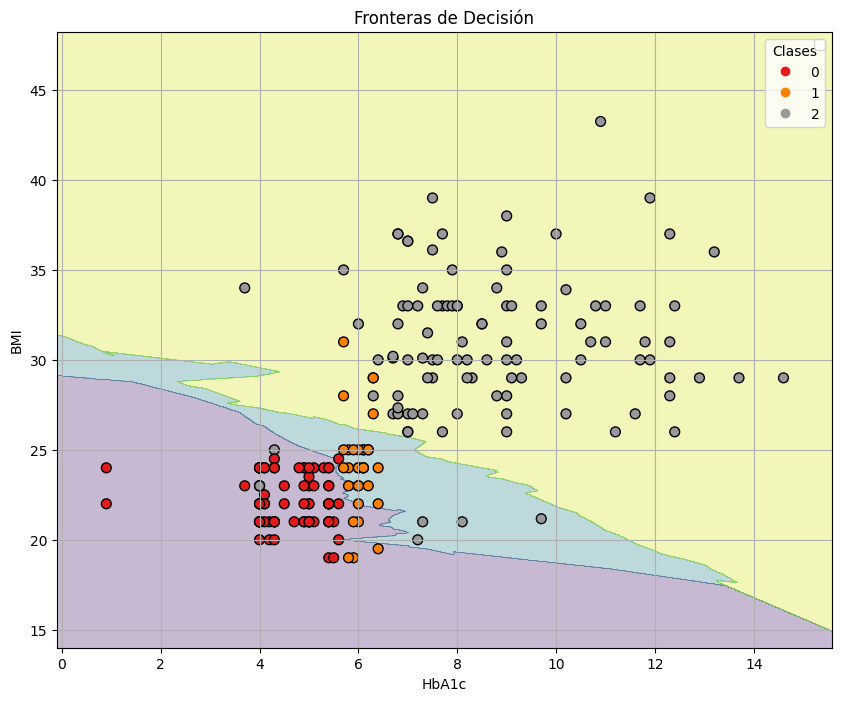

In [199]:
Z_knn_clase0 = Z_knn[:, 0].reshape(xx.shape)
Z_knn_clase1 = Z_knn[:, 1].reshape(xx.shape)
Z_knn_clase2 = Z_knn[:, 2].reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z_knn_predict, alpha=0.3)


scatter = plt.scatter(X_train2['HbA1c'], X_train2['BMI'], c = y_train2.to_numpy(), cmap=plt.cm.Set1, edgecolor = 'k', s = 50)

legend1 = plt.legend(*scatter.legend_elements(), title="Clases")
plt.gca().add_artist(legend1)

plt.xlabel('HbA1c')

plt.ylabel('BMI')

plt.title('Fronteras de Decisión')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
print(f'Accuracy 9NN con 2 columnas: {vmc2.accuracy(X_test2, y_test2)}')

Accuracy 9NN con 2 columnas: 0.8867924528301887


In [ ]:
print(f'Matriz de confusión para la clase 9NN con 2 columnas: \n')
print(vmc2.matriz_de_confusion(X_test2, y_test2))

Matriz de confusión para la clase 9NN con 2 columnas: 

[[17.  1.  0.]
 [ 3.  6.  1.]
 [ 0.  1. 24.]]


In [ ]:
print(f"Macro F1 Score para 9NN con 2 columnas: {vmc2.macro_F1(X_test2, y_test2)}")

Macro F1 Score para 9NN con 2 columnas: 0.8404678362573099


In [ ]:
vmc3 = KNN(X_train3, y_train3, 9)
vmc3.fit(X_train3, y_train3)

In [ ]:
print(f'Accuracy 9NN con 11 columnas: {vmc3.accuracy(X_test3, y_test3)}')

Accuracy 9NN con 11 columnas: 0.7358490566037735


In [ ]:
print(f'Matriz de confusión para la clase 9NN con 11 columnas: \n')
print(vmc3.matriz_de_confusion(X_test3, y_test3))

Matriz de confusión para la clase 9NN con 11 columnas: 

[[15.  0.  3.]
 [10.  0.  0.]
 [ 1.  0. 24.]]


In [ ]:
print(f"Macro F1 Score para 9NN con 11 columnas: {vmc3.macro_F1(X_test3, y_test3)}")

Macro F1 Score para 9NN con 11 columnas: 0.5349650349650349


Observación: cuantas más columnas agrego peor es el algoritmo